In [1]:
import matplotlib
matplotlib.use("Agg")
import plotly.io as pio
pio.renderers.default = "png"

# Pipeline examples (the infer "stat menu")

This page follows the R `infer`
[observed-statistic examples](https://infer.tidymodels.org/articles/observed_stat_examples.html)
vignette: the `calculate(stat=...)` forms organized by the **types of variables**
involved, using the same `gss` dataset (a sample from the US General Social
Survey) that ships with the package.

In [2]:
import moderndive as md
from moderndive import get_p_value, get_confidence_interval, assume

gss = md.load_gss()
gss.head()

year,age,sex,college,partyid,hompop,hours,income,class,finrela,weight
i64,i64,str,str,str,i64,i64,str,str,str,f64
2014,36,"""male""","""degree""","""ind""",3,50,"""$25000 or more""","""middle class""","""below average""",0.896003
1994,34,"""female""","""no degree""","""rep""",4,31,"""$20000 - 24999""","""working class""","""below average""",1.0825
1998,24,"""male""","""degree""","""ind""",1,40,"""$25000 or more""","""working class""","""below average""",0.5501
1996,42,"""male""","""no degree""","""ind""",4,40,"""$25000 or more""","""working class""","""above average""",1.0864
1994,31,"""male""","""degree""","""rep""",2,40,"""$25000 or more""","""middle class""","""above average""",1.0825


Throughout, the pattern is the same as in R `infer`:

- the **observed statistic** comes from `specify() → [hypothesize()] → calculate()`;
- a **null distribution** comes from adding `generate()` before `calculate()`;
- a **bootstrap distribution** (for confidence intervals) comes from
  `generate(type="bootstrap")` with no `hypothesize()`.

## One numerical variable

In [3]:
# mean
gss.specify(response="hours").calculate(stat="mean")

ObservedStatistic(stat='mean', value=41.382)

In [4]:
# median, then standard deviation
print(gss.specify(response="hours").calculate(stat="median"))
print(gss.specify(response="hours").calculate(stat="sd"))

ObservedStatistic(stat='median', value=40)
ObservedStatistic(stat='sd', value=14.82)


**Standardized mean (one-sample `t`)** — needs a hypothesized `mu`:

In [5]:
gss.specify(response="hours").hypothesize(null="point", mu=40).calculate(stat="t")

ObservedStatistic(stat='t', value=2.08519)

A full one-mean test — null distribution and p-value:

In [6]:
obs_mean = gss.specify(response="hours").calculate(stat="mean")
null_mean = (
    gss.specify(response="hours")
    .hypothesize(null="point", mu=40)
    .generate(reps=1000, type="bootstrap", seed=1)
    .calculate(stat="mean")
)
get_p_value(null_mean, obs_stat=obs_mean, direction="two-sided")

p_value
f64
0.03


…and a bootstrap confidence interval for the mean:

In [7]:
boot_mean = (
    gss.specify(response="hours")
    .generate(reps=1000, type="bootstrap", seed=1)
    .calculate(stat="mean")
)
get_confidence_interval(boot_mean, level=0.95, type="percentile")

lower_ci,upper_ci
f64,f64
40.12395,42.608


## One categorical variable

In [8]:
# proportion of a "success" level, then the raw count
print(gss.specify(response="sex", success="female").calculate(stat="prop"))
print(gss.specify(response="sex", success="female").calculate(stat="count"))

ObservedStatistic(stat='prop', value=0.474)
ObservedStatistic(stat='count', value=237)


**Standardized proportion (one-sample `z`)** — needs a hypothesized `p`:

In [9]:
gss.specify(response="sex", success="female").hypothesize(null="point", p=0.5).calculate(stat="z")

ObservedStatistic(stat='z', value=-1.16276)

A one-proportion test by *simulation* (`draw`, alias `simulate`):

In [10]:
obs_prop = gss.specify(response="sex", success="female").calculate(stat="prop")
null_prop = (
    gss.specify(response="sex", success="female")
    .hypothesize(null="point", p=0.5)
    .generate(reps=1000, type="draw", seed=1)
    .calculate(stat="prop")
)
get_p_value(null_prop, obs_stat=obs_prop, direction="two-sided")

p_value
f64
0.286


## One categorical variable (3+ levels): chi-square goodness-of-fit

Test whether the counts across a variable's levels match a set of hypothesized
proportions. Pass `p` as a `{level: probability}` mapping to
`hypothesize(null="point", ...)`, then `generate(type="draw")` to simulate from
those proportions:

In [11]:
levels = gss["finrela"].unique().to_list()
uniform = {level: 1 / len(levels) for level in levels}  # "all classes equally likely"

obs_gof = gss.specify(response="finrela").hypothesize(null="point", p=uniform).calculate(stat="Chisq")
null_gof = (
    gss.specify(response="finrela")
    .hypothesize(null="point", p=uniform)
    .generate(reps=1000, type="draw", seed=1)
    .calculate(stat="Chisq")
)
get_p_value(null_gof, obs_stat=obs_gof, direction="greater")

p_value
f64
0.0


The one-line wrapper is `chisq_test(gss, response="finrela", p=uniform)`.

## Two categorical variables (2 levels each)

In [12]:
# difference in proportions of "degree" between the sexes
gss.specify(formula="college ~ sex", success="degree").calculate(
    stat="diff in props", order=("male", "female")
)

ObservedStatistic(stat='diff in props', value=-0.00420337)

In [13]:
# ratio of proportions and the odds ratio
spec = gss.specify(formula="college ~ sex", success="degree")
print(spec.calculate(stat="ratio of props", order=("male", "female")))
print(spec.calculate(stat="odds ratio", order=("male", "female")))

ObservedStatistic(stat='ratio of props', value=0.987998)
ObservedStatistic(stat='odds ratio', value=0.981648)


**Standardized difference in proportions (`z`)**:

In [14]:
gss.specify(formula="college ~ sex", success="degree").calculate(
    stat="z", order=("male", "female")
)

ObservedStatistic(stat='z', value=-0.098526)

## Two categorical variables (chi-square test of independence)

In [15]:
obs_chisq = gss.specify(formula="finrela ~ sex").calculate(stat="Chisq")
obs_chisq

ObservedStatistic(stat='Chisq', value=9.1054)

In [16]:
null_chisq = (
    gss.specify(formula="finrela ~ sex")
    .hypothesize(null="independence")
    .generate(reps=1000, type="permute", seed=1)
    .calculate(stat="Chisq")
)
get_p_value(null_chisq, obs_stat=obs_chisq, direction="greater")

p_value
f64
0.1


A chi-square test is inherently one-sided; the theoretical distribution agrees:

In [17]:
n_levels_finrela = gss["finrela"].n_unique()
df_chisq = (n_levels_finrela - 1) * (gss["sex"].n_unique() - 1)
assume("Chisq", df=df_chisq).get_p_value(obs_chisq, direction="greater")

p_value
f64
0.104933


## One numerical and one categorical variable (2 levels)

In [18]:
# difference in mean age by college degree
gss.specify(formula="age ~ college").calculate(
    stat="diff in means", order=("degree", "no degree")
)

ObservedStatistic(stat='diff in means', value=0.94066)

In [19]:
# difference in medians, ratio of means, and the two-sample t
spec = gss.specify(formula="age ~ college")
print(spec.calculate(stat="diff in medians", order=("degree", "no degree")))
print(spec.calculate(stat="ratio of means", order=("degree", "no degree")))
print(spec.calculate(stat="t", order=("degree", "no degree")))

ObservedStatistic(stat='diff in medians', value=3)
ObservedStatistic(stat='ratio of means', value=1.02355)
ObservedStatistic(stat='t', value=0.802379)


Null distribution and p-value for the difference in means:

In [20]:
obs_diff = gss.specify(formula="age ~ college").calculate(
    stat="diff in means", order=("degree", "no degree")
)
null_diff = (
    gss.specify(formula="age ~ college")
    .hypothesize(null="independence")
    .generate(reps=1000, type="permute", seed=1)
    .calculate(stat="diff in means", order=("degree", "no degree"))
)
get_p_value(null_diff, obs_stat=obs_diff, direction="two-sided")

p_value
f64
0.44


## One numerical and one categorical variable (3+ levels): ANOVA F

In [21]:
gss.specify(formula="age ~ partyid").calculate(stat="F")

ObservedStatistic(stat='F', value=2.48421)

## Two numerical variables

In [22]:
# Pearson correlation, then the regression slope
print(gss.specify(formula="hours ~ age").calculate(stat="correlation"))
print(gss.specify(formula="hours ~ age").calculate(stat="slope"))

ObservedStatistic(stat='correlation', value=0.00701719)
ObservedStatistic(stat='slope', value=0.00780766)


A permutation test for the slope, visualized:

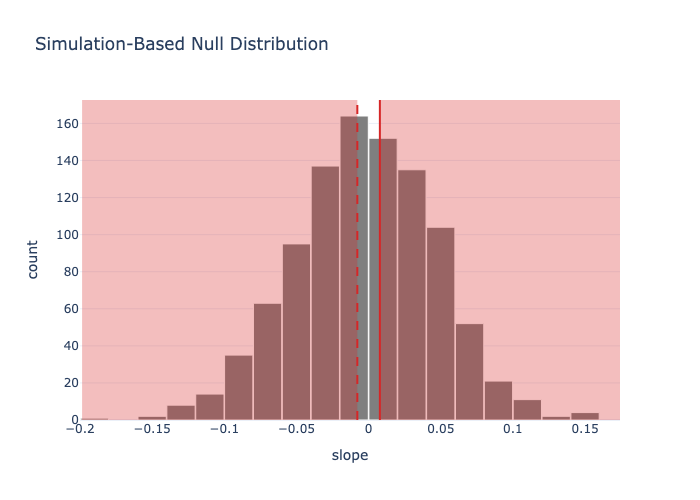

In [23]:
from moderndive import visualize, shade_p_value

obs_slope = gss.specify(formula="hours ~ age").calculate(stat="slope")
null_slope = (
    gss.specify(formula="hours ~ age")
    .hypothesize(null="independence")
    .generate(reps=1000, type="permute", seed=1)
    .calculate(stat="slope")
)
visualize(null_slope) + shade_p_value(obs_stat=obs_slope, direction="two-sided")

## Custom statistics

Any of the above can be swapped for a callable returning a single number — see the
custom-statistic example in {doc}`hypothesis-testing`.